##Importing Necessary Libraries



In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [33]:
data =  pd.read_csv('/content/shopping_trends.csv')

##data exploration

In [34]:
data.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [35]:
data.shape

(3900, 19)

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [37]:
# check Missing value
data.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [38]:
# Check Duplication
data.duplicated().sum()

np.int64(0)

In [39]:
# Check the number of unique values of each column
data.nunique()

,0
Customer ID,3900
Age,53
Gender,2
Item Purchased,25
Category,4
Purchase Amount (USD),81
Location,50
Size,4
Color,25
Season,4


In [40]:
# Check statistic of dataset
data.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


##Let's start checking the unique values for each column

In [41]:
for col in data.columns:
    print(f'Category in {col} is :\n {data[col].unique()}\n')
    print('\\'*50)

Category in Customer ID is :
 [   1    2    3 ... 3898 3899 3900]

\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
Category in Age is :
 [55 19 50 21 45 46 63 27 26 57 53 30 61 65 64 25 52 66 31 56 18 38 54 33
 36 35 29 70 69 67 20 39 42 68 49 59 47 40 41 48 22 24 44 37 58 32 62 51
 28 43 34 23 60]

\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
Category in Gender is :
 ['Male' 'Female']

\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
Category in Item Purchased is :
 ['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']

\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
Category in Category is :
 ['Clothing' 'Footwear' 'Outerwear' 'Accessories']

\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
Category in Purchase Amount (USD) is :
 [ 53  64  73  90  49  20  85  34  97  31  68  72  51  81  36  38  48 

##Analysis📝 & Visualiation📊

In [42]:
# Drop Column Customer ID because it is not important in the analysis
data=data.drop(['Customer ID'],axis=1)

In [43]:
data.Age.describe()

,Age
count,3900.000000
mean,44.068462
std,15.207589
min,18.000000
25%,31.000000
50%,44.000000
75%,57.000000
max,70.000000


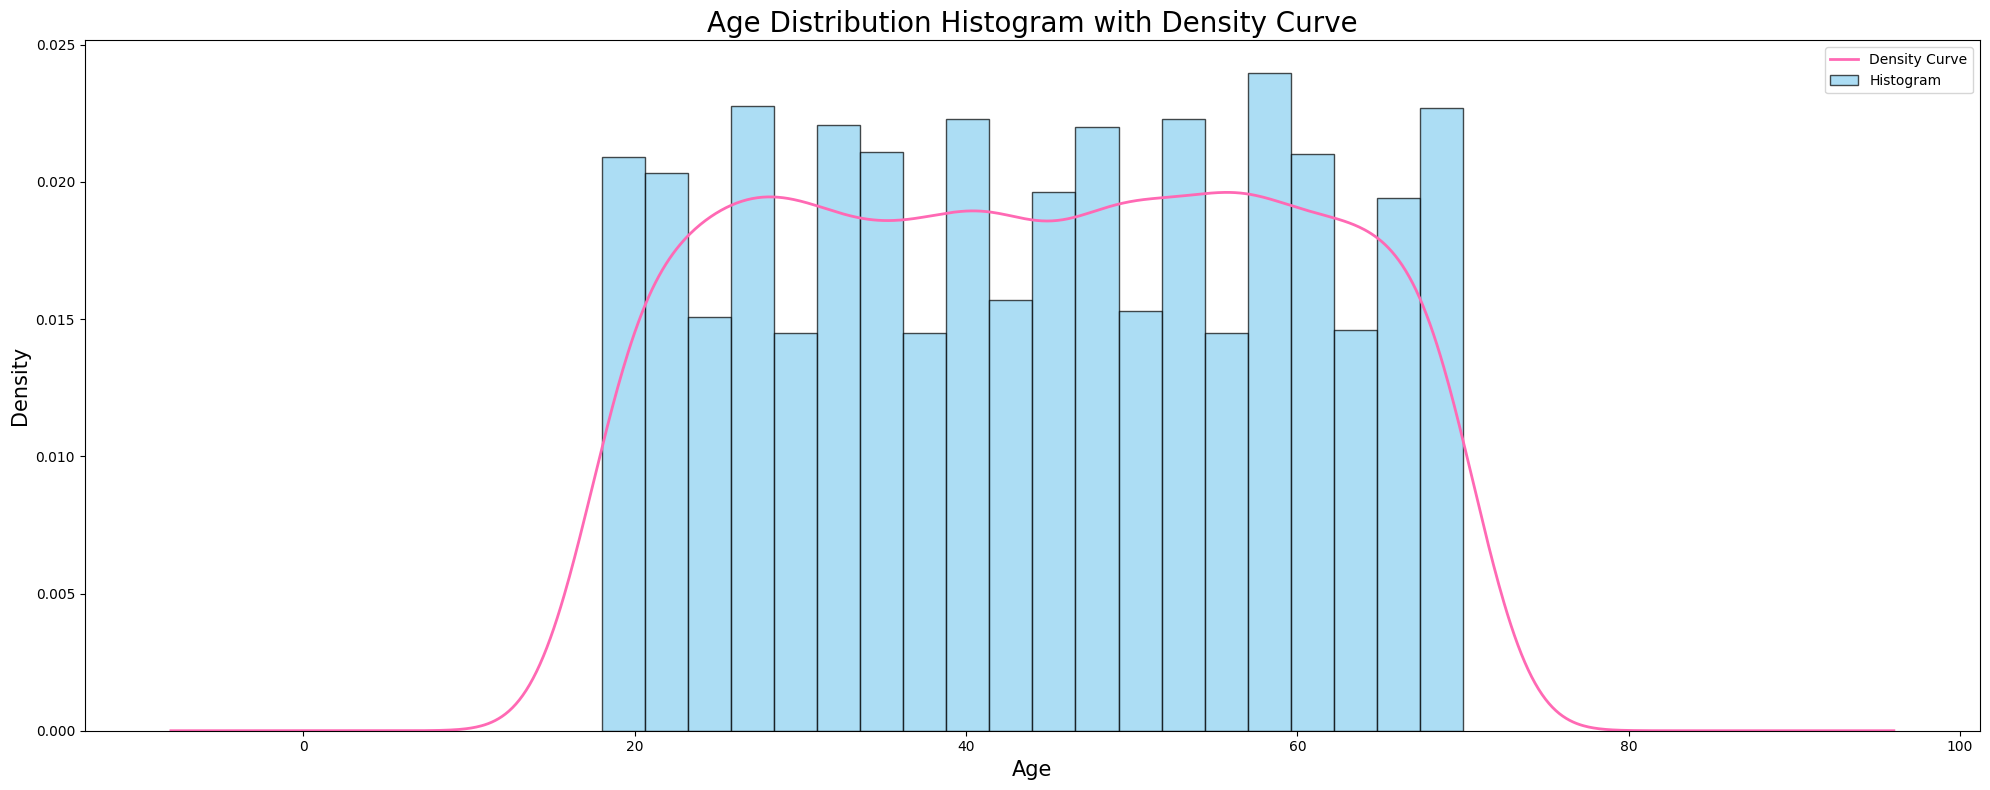

In [44]:
# Assuming 'data' is your DataFrame with an 'Age' column
fig, ax = plt.subplots(figsize=(20, 8))

# Histogram (set density=True to match with KDE)
ax.hist(data['Age'], bins=20, edgecolor='black', alpha=0.7, color="#89CFF0", density=True)

# KDE (density curve)
data['Age'].plot(kind='kde', color="#FF69B4", linewidth=2, ax=ax)

# Labels and title
ax.set_xlabel('Age', fontsize=15)
ax.set_ylabel('Density', fontsize=15)
ax.set_title('Age Distribution Histogram with Density Curve', fontsize=20)
ax.legend(['Density Curve', 'Histogram'])

plt.tight_layout()
plt.show()


Gender
Male      2652
Female    1248
Name: count, dtype: int64 



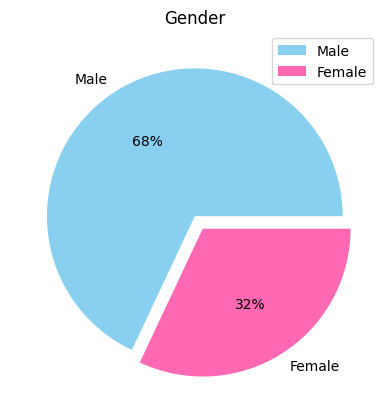

In [45]:
gender = data.Gender.value_counts()
print(gender,'\n')

plt.pie(gender,labels=gender.index,colors=["#89CFF0", "#FF69B4"],autopct='%.0f%%',explode=(0,0.1))
plt.legend(labels = gender.index, loc = "best")
plt.title('Gender')
plt.show()

In [48]:
data['Item Purchased'].value_counts()

,count
Item Purchased,
Blouse,171
Pants,171
Jewelry,171
Shirt,169
Dress,166
Sweater,164
Jacket,163
Coat,161
Sunglasses,161


/tmp/ipython-input-49-345549188.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data= data, x='Item Purchased',palette='cool')


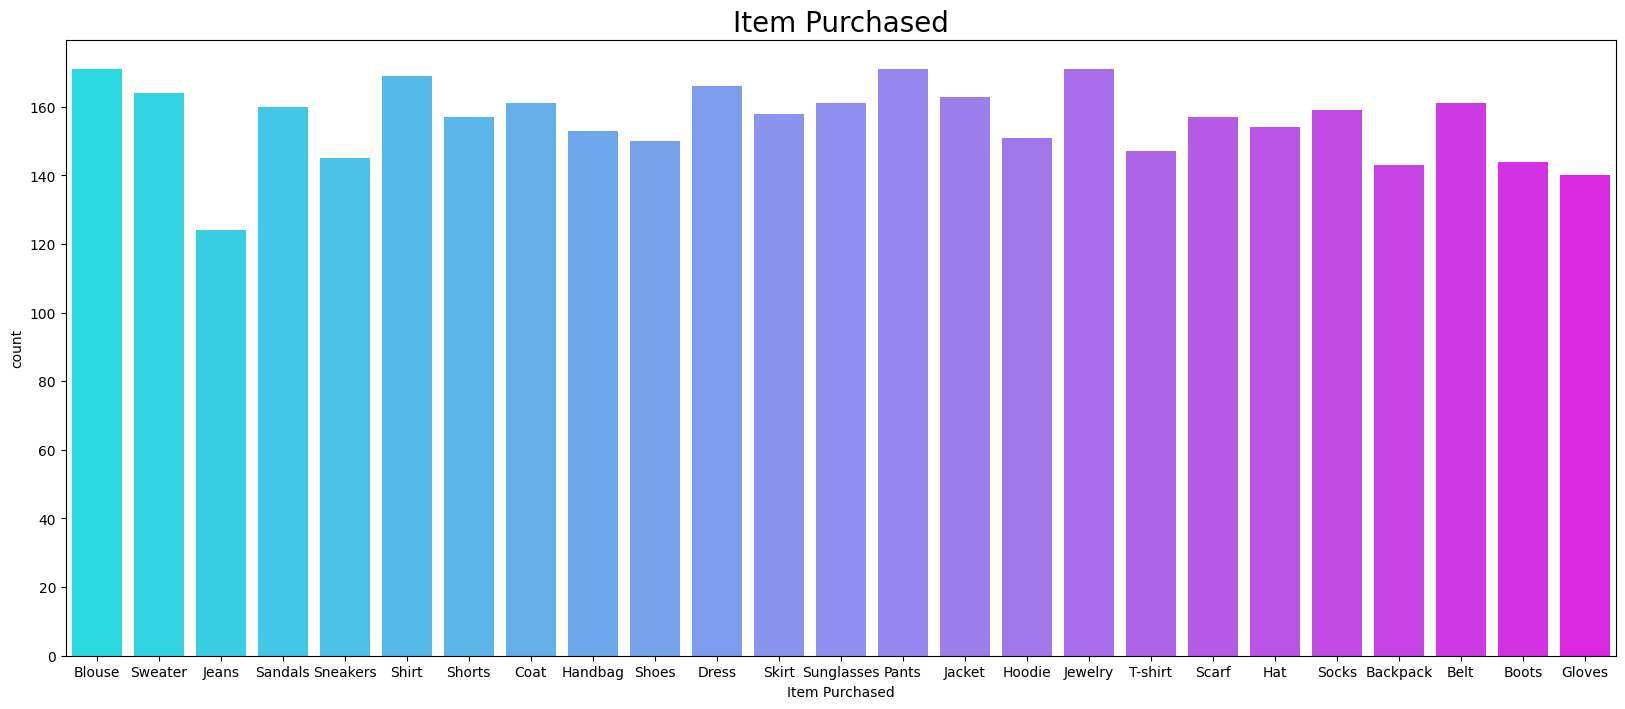

In [49]:
plt.subplots(figsize=(20,8), dpi=100)
sns.countplot(data= data, x='Item Purchased',palette='cool')
plt.title("Item Purchased",fontsize=20)
plt.show()

In [50]:
CountOfCategory = data['Category'].value_counts()
CountOfCategory

,count
Category,
Clothing,1737
Accessories,1240
Footwear,599
Outerwear,324


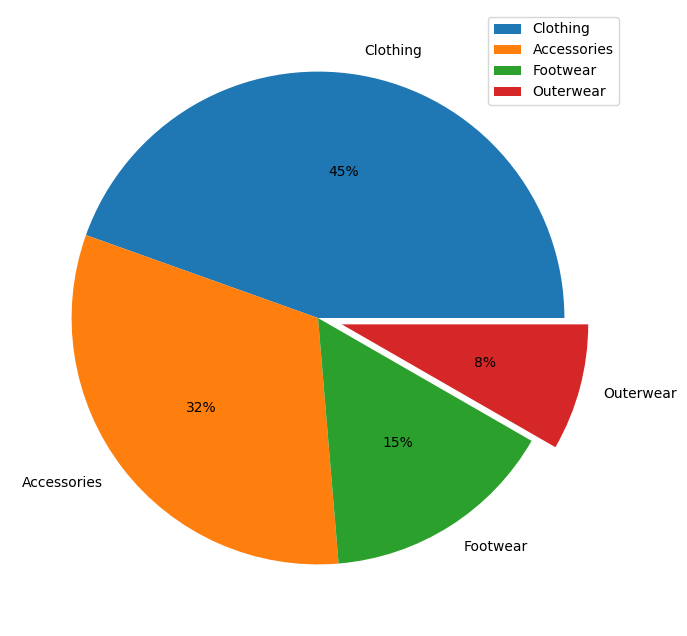

In [51]:
plt.figure(figsize=(8,8))
plt.pie(CountOfCategory,labels=CountOfCategory.index,autopct='%0.0f%%',explode=(0,0,0,0.1))
plt.legend(CountOfCategory.index,loc =1)
plt.show()

In [52]:
data['Purchase Amount (USD)'].describe()

,Purchase Amount (USD)
count,3900.000000
mean,59.764359
std,23.685392
min,20.000000
25%,39.000000
50%,60.000000
75%,81.000000
max,100.000000


In [53]:
data['Location'].value_counts()

,count
Location,
Montana,96
California,95
Idaho,93
Illinois,92
Alabama,89
Minnesota,88
New York,87
Nevada,87
Nebraska,87


/tmp/ipython-input-54-2233893894.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_Location, y=top_10_Location.index,palette='cool',linewidth = 4)


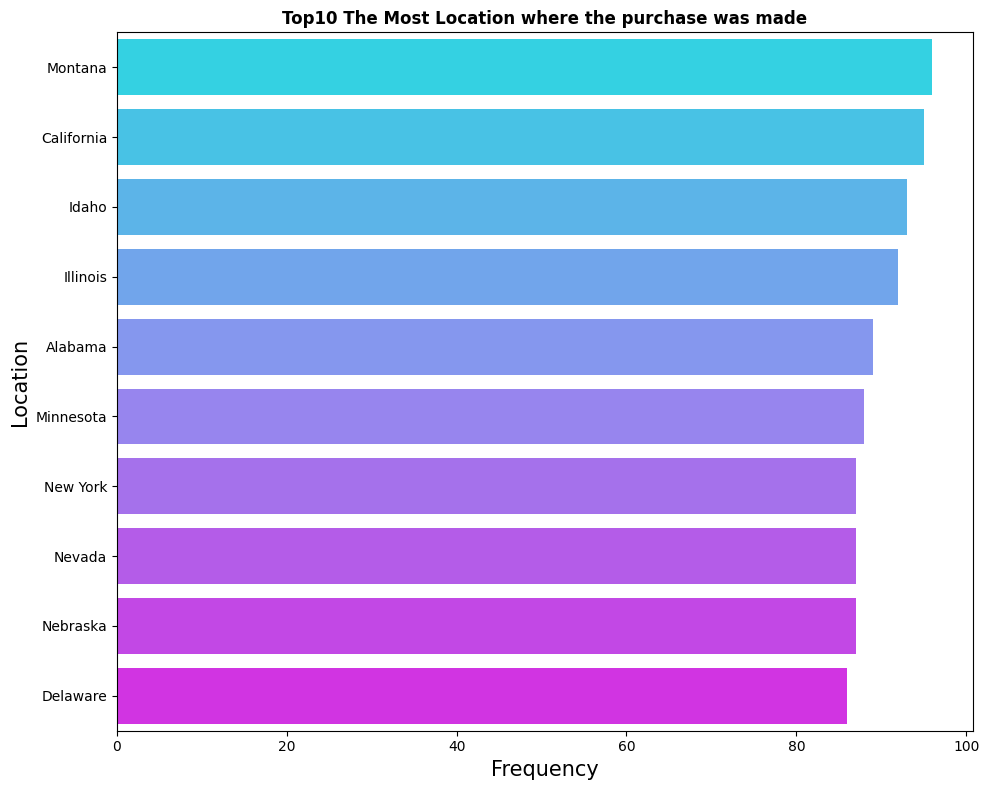

In [54]:
top_10_Location = data.Location.value_counts().sort_values(ascending=False)[:10]
plt.figure(figsize=(10, 8))
sns.barplot(x=top_10_Location, y=top_10_Location.index,palette='cool',linewidth = 4)
plt.title('Top10 The Most Location where the purchase was made',loc='center',fontweight='bold',fontsize=12)
plt.xlabel('Frequency',fontsize=15)
plt.ylabel('Location',fontsize=15)
plt.tight_layout()
plt.show()

In [55]:
size_count = data['Size'].value_counts()
size_count

,count
Size,
M,1755
L,1053
S,663
XL,429


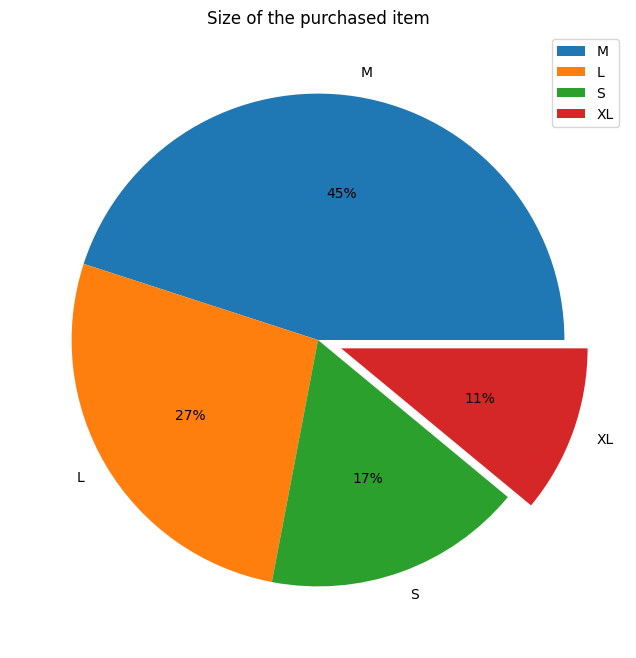

In [56]:
plt.figure(figsize=(8,8))
plt.pie(size_count,labels=['M','L','S','XL'],autopct='%0.0f%%',explode=(0,0,0,0.1))
plt.legend( ['M','L','S','XL'],loc =1)
plt.title('Size of the purchased item')
plt.show()

In [57]:
data['Color'].value_counts()

,count
Color,
Olive,177
Yellow,174
Silver,173
Teal,172
Green,169
Black,167
Cyan,166
Violet,166
Gray,159


/tmp/ipython-input-58-1814170817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Color, y=Color.index,palette='cool',linewidth = 4)


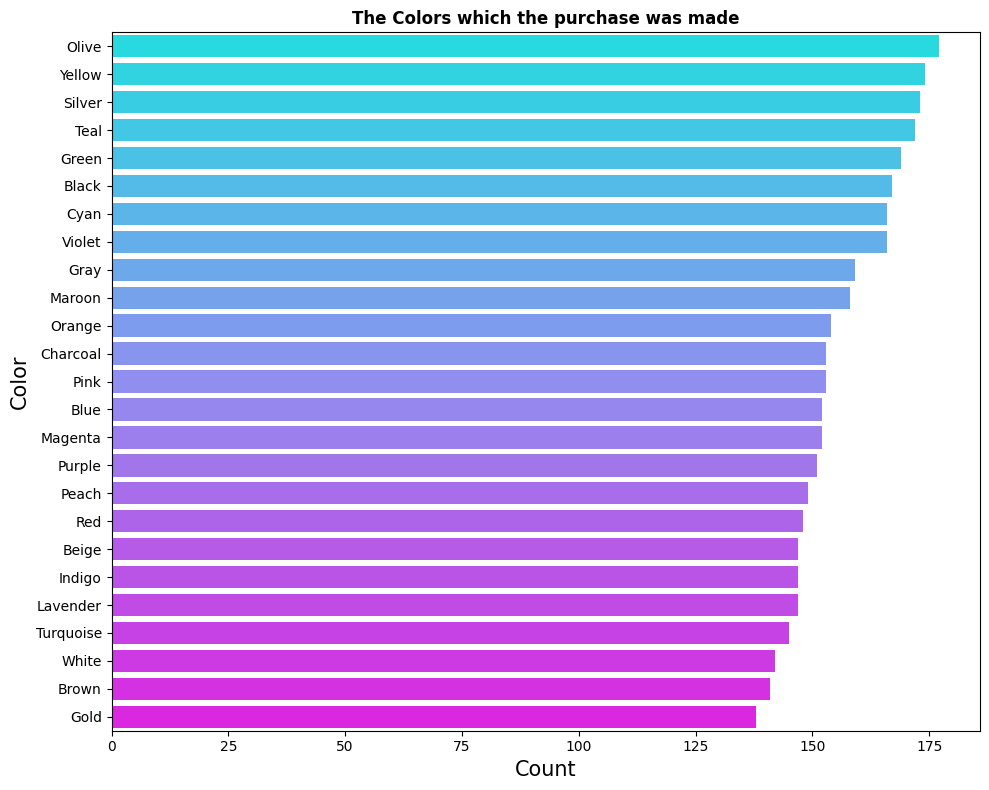

In [58]:
Color = data['Color'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=Color, y=Color.index,palette='cool',linewidth = 4)
plt.title('The Colors which the purchase was made',loc='center',fontweight='bold',fontsize=12)
plt.xlabel('Count',fontsize=15)
plt.ylabel('Color',fontsize=15)
plt.tight_layout()
plt.show()

In [59]:
season = data['Season'].value_counts()
season

,count
Season,
Spring,999
Fall,975
Winter,971
Summer,955


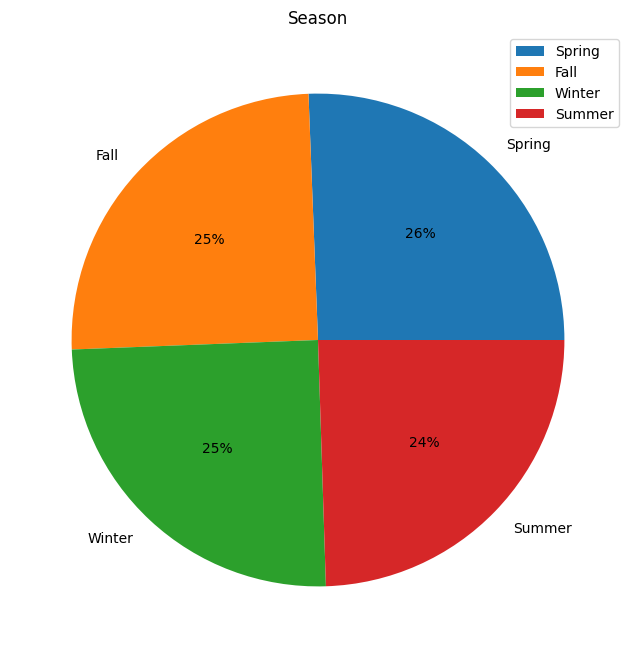

In [60]:
plt.figure(figsize=(8,8))
plt.pie(season,labels=['Spring','Fall','Winter','Summer'],autopct='%0.0f%%')
plt.legend( ['Spring','Fall','Winter','Summer'],loc =1)
plt.title('Season')
plt.show()

In [61]:
data['Review Rating'].describe()

,Review Rating
count,3900.000000
mean,3.749949
std,0.716223
min,2.500000
25%,3.100000
50%,3.700000
75%,4.400000
max,5.000000


In [62]:
count = data['Subscription Status'].value_counts()
count

,count
Subscription Status,
No,2847
Yes,1053


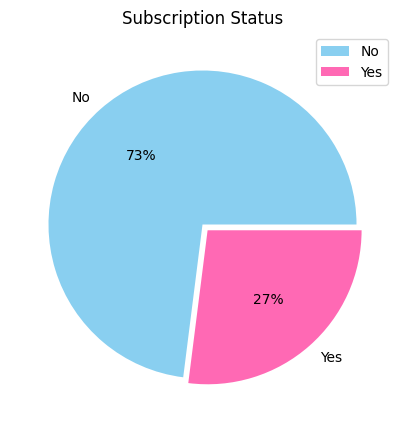

In [63]:
plt.figure(figsize=(5,5))
plt.pie(count,labels=['No','Yes'],colors=["#89CFF0", "#FF69B4"],autopct='%0.0f%%',explode=(0,0.05))
plt.legend( ['No','Yes'],loc =1)
plt.title('Subscription Status')
plt.show()

In [64]:
Shipping_Type = data['Shipping Type'].value_counts()
Shipping_Type

,count
Shipping Type,
Free Shipping,675
Standard,654
Store Pickup,650
Next Day Air,648
Express,646
2-Day Shipping,627


/tmp/ipython-input-65-2551737901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Shipping_Type.index,y=Shipping_Type, palette='cool',linewidth = 5)


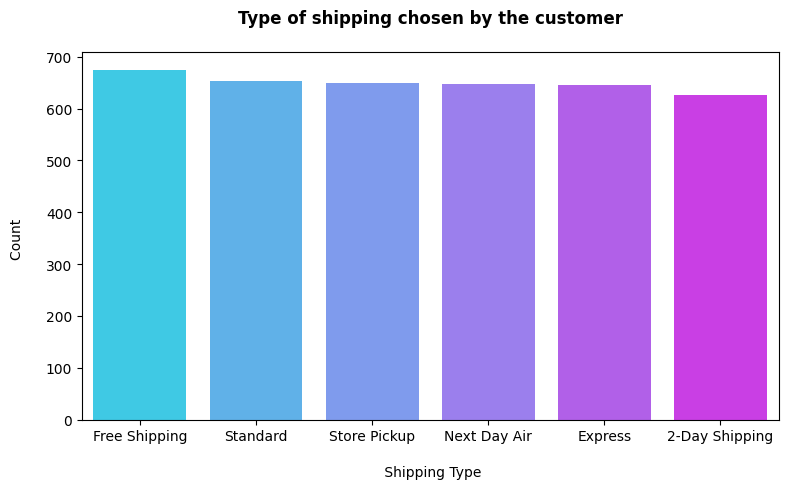

In [65]:
plt.figure(figsize=(8, 5))
sns.barplot(x=Shipping_Type.index,y=Shipping_Type, palette='cool',linewidth = 5)
plt.title('Type of shipping chosen by the customer\n',loc='center',fontweight='bold',fontsize=12)
plt.xlabel('\n Shipping Type',fontsize=10)
plt.ylabel('Count \n',fontsize=10)
plt.tight_layout()
plt.show()

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64


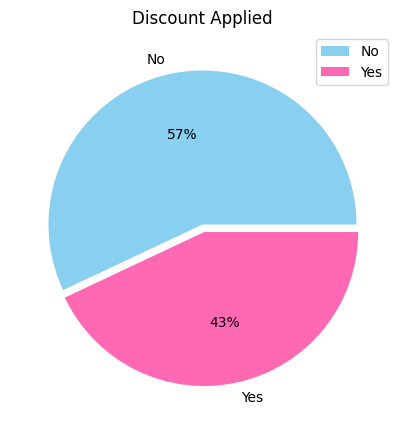

In [66]:
Discount_Applied =data['Discount Applied'].value_counts()
print(Discount_Applied)
plt.figure(figsize=(5,5))
plt.pie(Discount_Applied,labels=['No','Yes'],colors=["#89CFF0", "#FF69B4"],autopct='%0.0f%%',explode=(0,0.05))
plt.legend( ['No','Yes'],loc =1)
plt.title('Discount Applied')
plt.show()

Promo Code Used
No     2223
Yes    1677
Name: count, dtype: int64


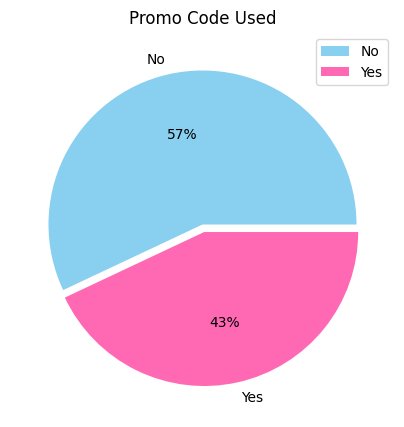

In [67]:
Promo_Code_Used =data['Promo Code Used'].value_counts()
print(Promo_Code_Used)
plt.figure(figsize=(5,5))
plt.pie(Promo_Code_Used,labels=['No','Yes'],colors=["#89CFF0", "#FF69B4"],autopct='%0.0f%%',explode=(0,0.05))
plt.legend( ['No','Yes'],loc =1)
plt.title('Promo Code Used')
plt.show()

In [68]:
Payment_Method = data['Payment Method'].value_counts()
Payment_Method

,count
Payment Method,
Credit Card,696
Venmo,653
Cash,648
PayPal,638
Debit Card,633
Bank Transfer,632


/tmp/ipython-input-69-865791163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Payment_Method.index,y=Payment_Method, palette='cool',linewidth = 5)


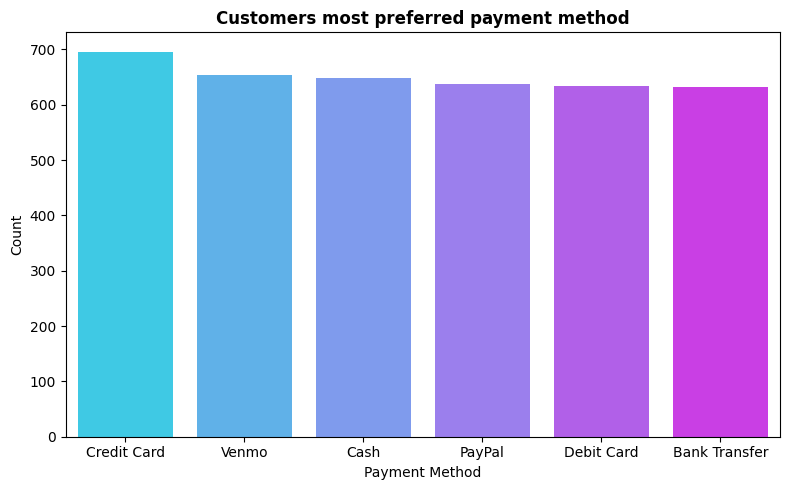

In [69]:
plt.figure(figsize=(8, 5))
sns.barplot(x=Payment_Method.index,y=Payment_Method, palette='cool',linewidth = 5)
plt.title('Customer''s most preferred payment method',loc='center',fontweight='bold',fontsize=12)
plt.xlabel('Payment Method',fontsize=10)
plt.ylabel('Count',fontsize=10)
plt.tight_layout()
plt.show()

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64


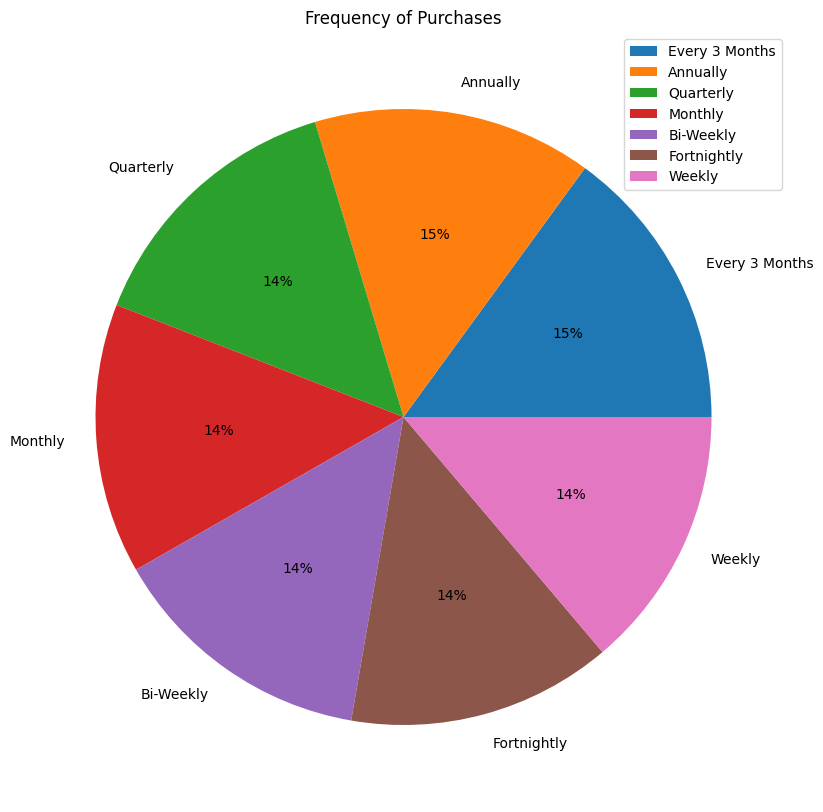

In [70]:
Frequency_of_Purchases =data['Frequency of Purchases'].value_counts()
print(Frequency_of_Purchases)
plt.figure(figsize=(10,10))
plt.pie(Frequency_of_Purchases,labels=Frequency_of_Purchases.index,autopct='%0.0f%%')
plt.legend( Frequency_of_Purchases.index,loc =1)
plt.title('Frequency of Purchases')
plt.show()

Gender          Female  Male
Item Purchased              
Backpack            37   106
Belt                55   106
Blouse              66   105
Boots               50    94
Coat                47   114
Dress               52   114
Gloves              37   103
Handbag             58    95
Hat                 52   102
Hoodie              51   100
Jacket              54   109
Jeans               29    95
Jewelry             52   119
Pants               48   123
Sandals             59   101
Scarf               45   112
Shirt               59   110
Shoes               48   102
Shorts              48   109
Skirt               49   109
Sneakers            42   103
Socks               58   101
Sunglasses          56   105
Sweater             50   114
T-shirt             46   101 
##################################################
Gender       Female  Male
Category                 
Accessories     392   848
Clothing        556  1181
Footwear        199   400
Outerwear       101   223 
########

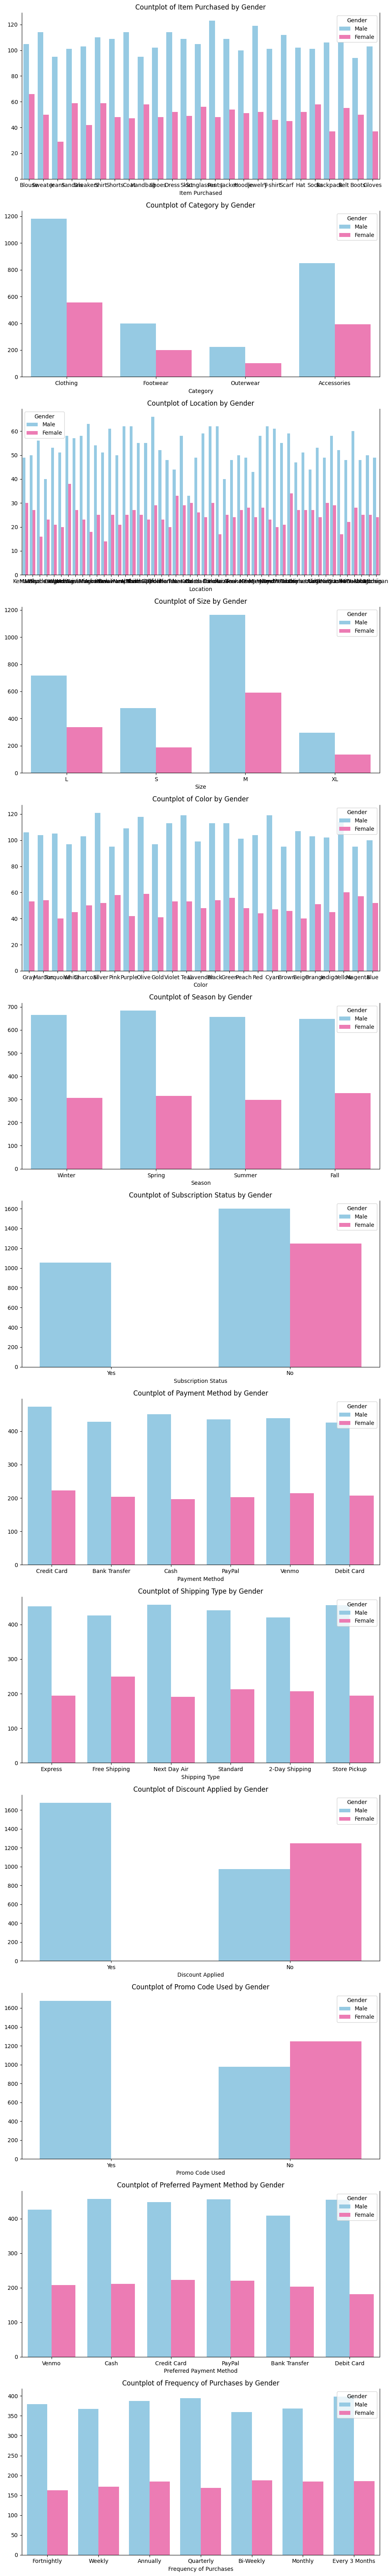

In [95]:

# Total number of plots = number of columns
num_plots = len(df.columns)

fig, axes = plt.subplots(nrows=num_plots, ncols=1, figsize=(10, 5 * num_plots))

# If there's only one column, axes may not be iterable
if num_plots == 1:
    axes = [axes]

for idx, col in enumerate(df.columns):
    print(pd.crosstab(data['Gender'], data[col]).T, '\n' + '#' * 50)
    sns.countplot(data=data, hue='Gender', x=col, palette=["#89CFF0", "#FF69B4"], ax=axes[idx])
    axes[idx].set_title(f"Countplot of {col} by Gender")
    axes[idx].set_ylabel('')
    axes[idx].spines['top'].set_visible(False)

plt.tight_layout()
plt.show()


In [72]:
pd.crosstab(data['Gender'], data['Category'], values=data['Age'],aggfunc=np.average)

Category,Accessories,Clothing,Footwear,Outerwear
Gender,,,,
Female,44.283163,43.620504,44.482412,44.128713
Male,44.196934,43.859441,44.422500,44.394619


In [73]:
data.groupby('Gender')['Purchase Amount (USD)'].sum()

,Purchase Amount (USD)
Gender,
Female,75191
Male,157890


<Axes: xlabel='Gender', ylabel='Purchase Amount (USD)'>

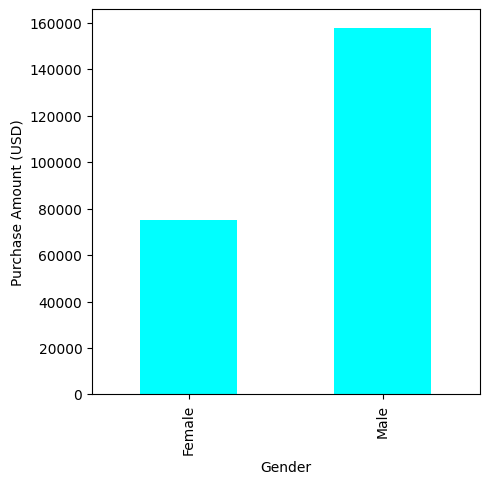

In [74]:
data.groupby('Gender')['Purchase Amount (USD)'].sum().plot(kind='bar',figsize=(5,5),colormap='cool',ylabel='Purchase Amount (USD)')

In [75]:
pd.crosstab(data['Category'],data['Item Purchased']).T

Category,Accessories,Clothing,Footwear,Outerwear
Item Purchased,,,,
Backpack,143,0,0,0
Belt,161,0,0,0
Blouse,0,171,0,0
Boots,0,0,144,0
Coat,0,0,0,161
Dress,0,166,0,0
Gloves,140,0,0,0
Handbag,153,0,0,0
Hat,154,0,0,0


<Axes: xlabel='Category'>

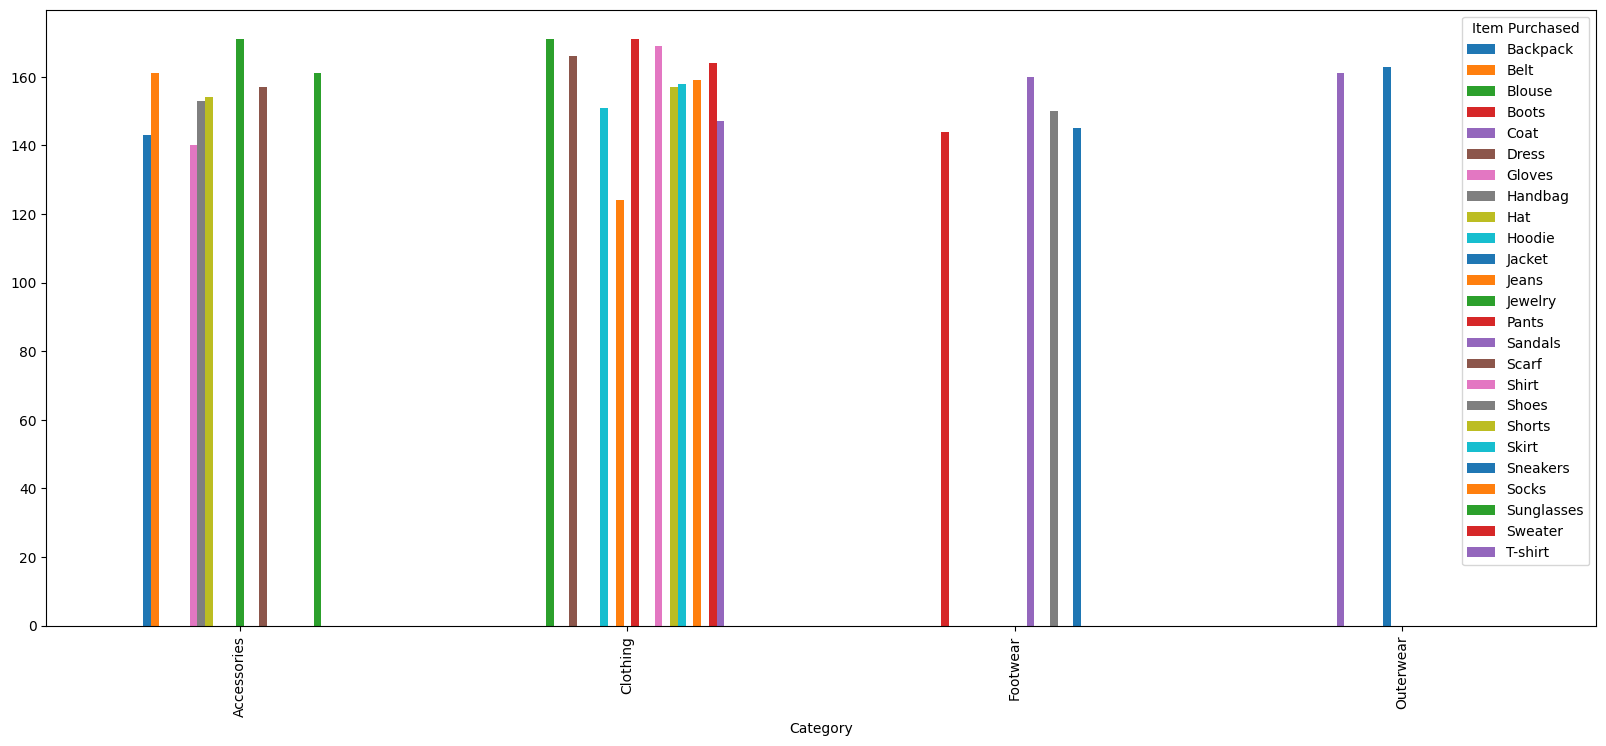

In [76]:
pd.crosstab(data['Category'],data['Item Purchased']).plot(kind='bar',figsize=(20,8))

In [77]:
data.groupby(['Gender','Category'])['Purchase Amount (USD)'].sum()

Gender  Category   
Female  Accessories    23819
        Clothing       33636
        Footwear       11835
        Outerwear       5901
Male    Accessories    50381
        Clothing       70628
        Footwear       24258
        Outerwear      12623
Name: Purchase Amount (USD), dtype: int64

<Axes: xlabel='Gender,Category', ylabel='Purchase Amount (USD)'>

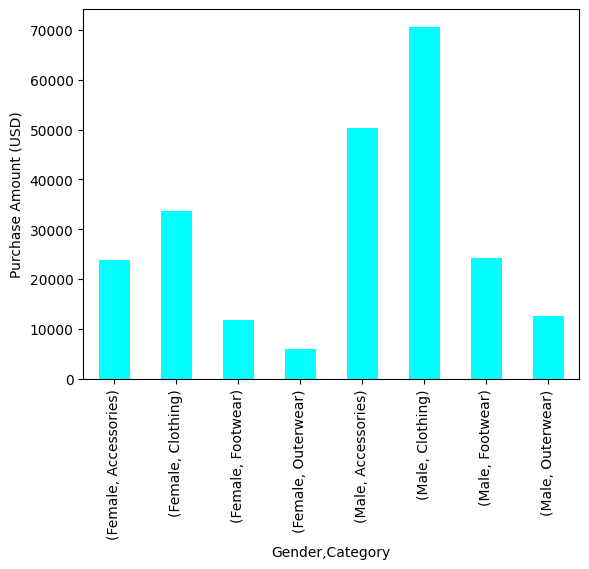

In [78]:
data.groupby(['Gender','Category'])['Purchase Amount (USD)'].sum().plot(kind='bar',colormap='cool',ylabel='Purchase Amount (USD)')

In [79]:
data.groupby(['Category','Item Purchased'])['Purchase Amount (USD)'].sum()

Category     Item Purchased
Accessories  Backpack           8636
             Belt               9635
             Gloves             8477
             Handbag            8857
             Hat                9375
             Jewelry           10010
             Scarf              9561
             Sunglasses         9649
Clothing     Blouse            10410
             Dress             10320
             Hoodie             8767
             Jeans              7548
             Pants             10090
             Shirt             10332
             Shorts             9433
             Skirt              9402
             Socks              9252
             Sweater            9462
             T-shirt            9248
Footwear     Boots              9018
             Sandals            9200
             Shoes              9240
             Sneakers           8635
Outerwear    Coat               9275
             Jacket             9249
Name: Purchase Amount (USD), dtype: int64

<Axes: xlabel='Category,Item Purchased', ylabel='Purchase Amount (USD)'>

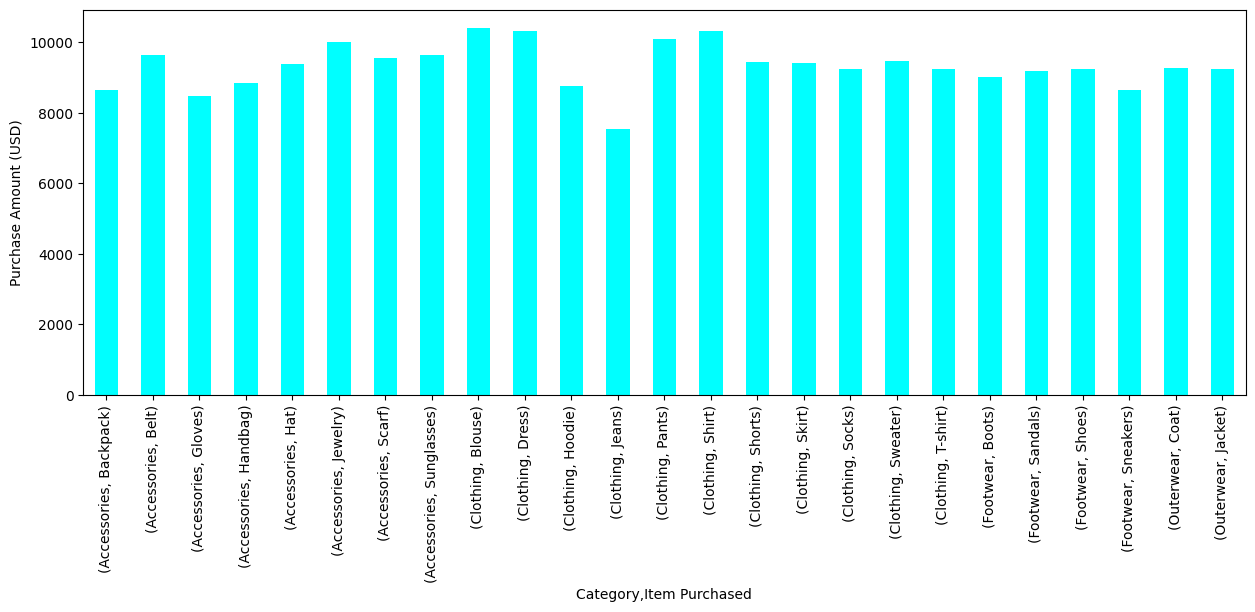

In [80]:
data.groupby(['Category','Item Purchased'])['Purchase Amount (USD)'].sum().plot(kind='bar',colormap='cool',figsize=(15,5),ylabel='Purchase Amount (USD)')

In [81]:
pd.crosstab(data['Season'],data['Category'])

Category,Accessories,Clothing,Footwear,Outerwear
Season,,,,
Fall,324,427,136,88
Spring,301,454,163,81
Summer,312,408,160,75
Winter,303,448,140,80


<Axes: xlabel='Season', ylabel='Count'>

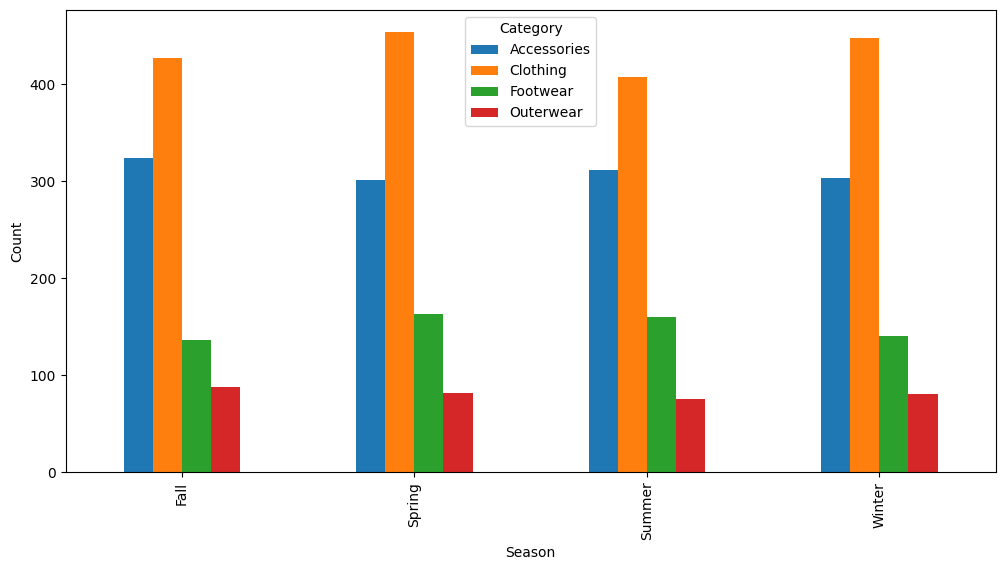

In [82]:
pd.crosstab(data['Season'],data['Category']).plot(kind='bar',figsize=(12,6),ylabel='Count')

In [83]:
pd.crosstab(data['Season'],data['Item Purchased']).T

Season,Fall,Spring,Summer,Winter
Item Purchased,,,,
Backpack,34,39,45,25
Belt,41,41,39,40
Blouse,42,46,43,40
Boots,35,40,38,31
Coat,34,46,42,39
Dress,36,43,47,40
Gloves,37,42,29,32
Handbag,48,36,35,34
Hat,50,27,37,40


<Axes: xlabel='Item Purchased', ylabel='Count'>

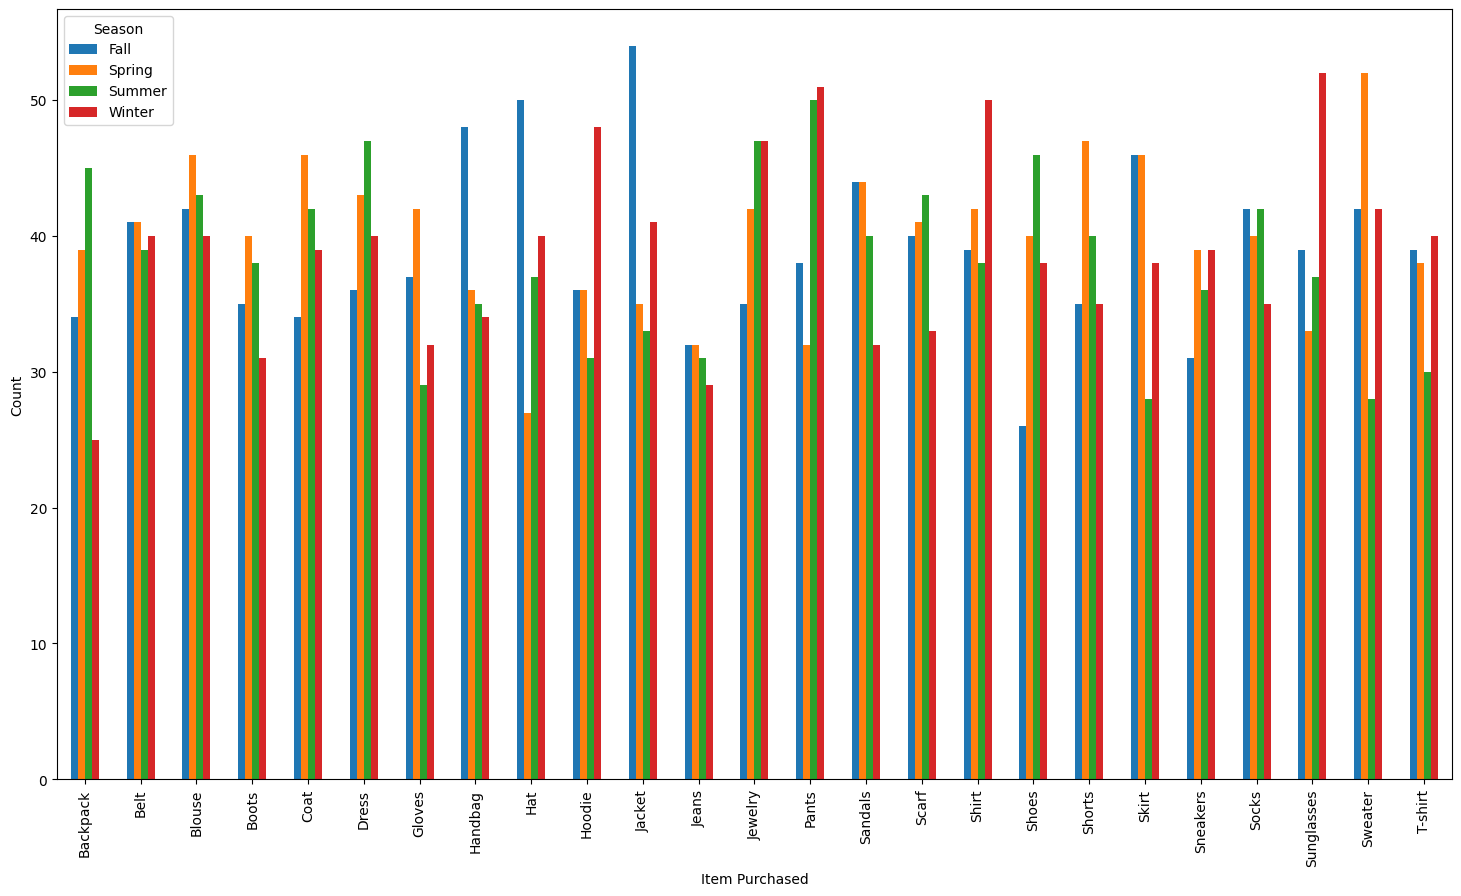

In [84]:
pd.crosstab(data['Item Purchased'],data['Season']).plot(kind='bar',figsize=(18,10),ylabel='Count')

In [85]:
pd.crosstab(data['Season'],data['Category'],values=data['Purchase Amount (USD)'],aggfunc=np.sum)

/tmp/ipython-input-85-3044580594.py:1: FutureWarning: The provided callable <function sum at 0x7c582ce79300> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pd.crosstab(data['Season'],data['Category'],values=data['Purchase Amount (USD)'],aggfunc=np.sum)


Category,Accessories,Clothing,Footwear,Outerwear
Season,,,,
Fall,19874,26220,8665,5259
Spring,17007,27692,9555,4425
Summer,19028,23078,9393,4278
Winter,18291,27274,8480,4562


/tmp/ipython-input-86-1293484778.py:1: FutureWarning: The provided callable <function sum at 0x7c582ce79300> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  pd.crosstab(data['Season'],data['Category'],values=data['Purchase Amount (USD)'],aggfunc=np.sum).plot(kind='bar',figsize=(12,6),ylabel='Purchase Amount (USD)')


<Axes: xlabel='Season', ylabel='Purchase Amount (USD)'>

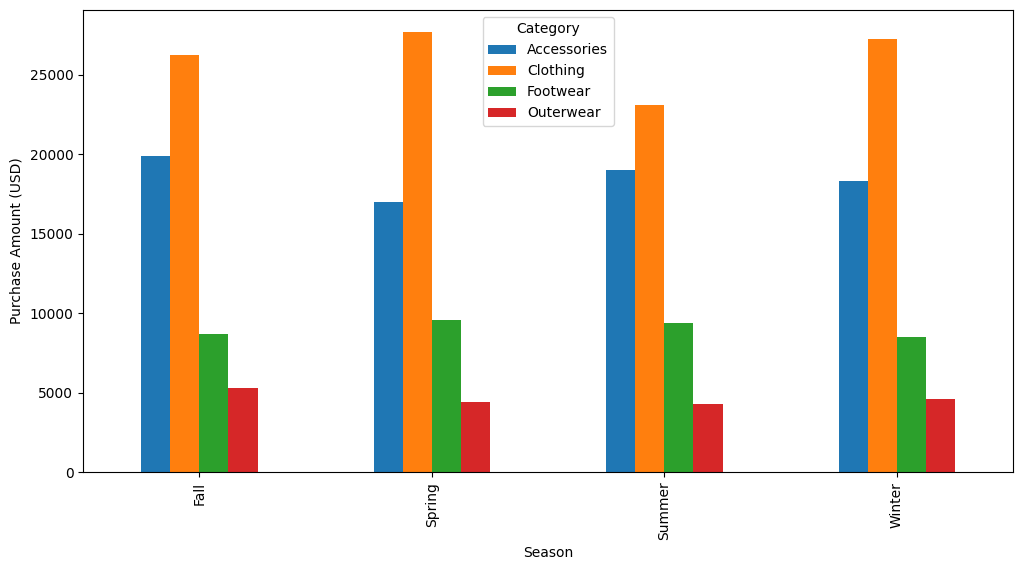

In [86]:
pd.crosstab(data['Season'],data['Category'],values=data['Purchase Amount (USD)'],aggfunc=np.sum).plot(kind='bar',figsize=(12,6),ylabel='Purchase Amount (USD)')

In [87]:
pd.crosstab(data['Season'],data['Purchase Amount (USD)'].sum())

col_0,233081
Season,
Fall,975
Spring,999
Summer,955
Winter,971


Text(0.5, 1.0, 'Purchase Amount by Season')

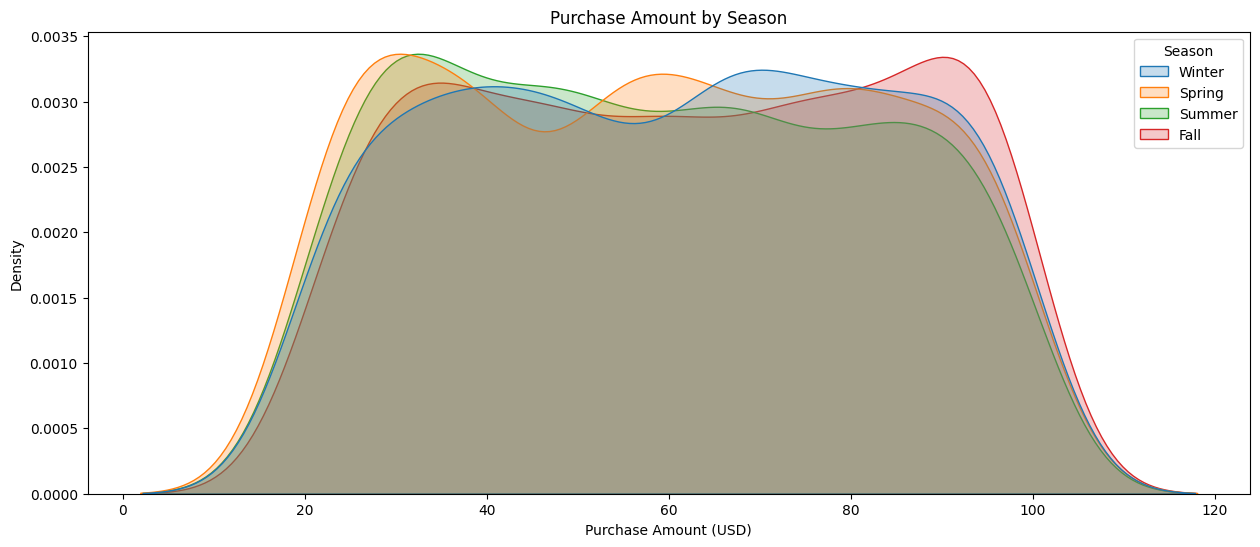

In [88]:
plt.figure(figsize=(15, 6))
sns.kdeplot(data= data, x='Purchase Amount (USD)',hue='Season',fill=True)
plt.title('Purchase Amount by Season')

In [89]:
data[data['Category'] == 'Clothing'].groupby('Size')['Purchase Amount (USD)'].sum()

,Purchase Amount (USD)
Size,
L,27864
M,47041
S,17416
XL,11943


In [91]:
data1 = pd.read_csv('/content/shopping_trends_updated.csv')

In [92]:
data1[(data1['Subscription Status'] == 'Yes') & (data1['Promo Code Used'] == 'Yes')]['Customer ID'].count()

np.int64(1053)

In [93]:
data1[data1['Previous Purchases'] > 40]['Customer ID'].count()

np.int64(765)

In [94]:
data[(data['Gender'] == 'Female') & (data['Review Rating'] >= 3)]['Category'].mode()[0]

'Clothing'

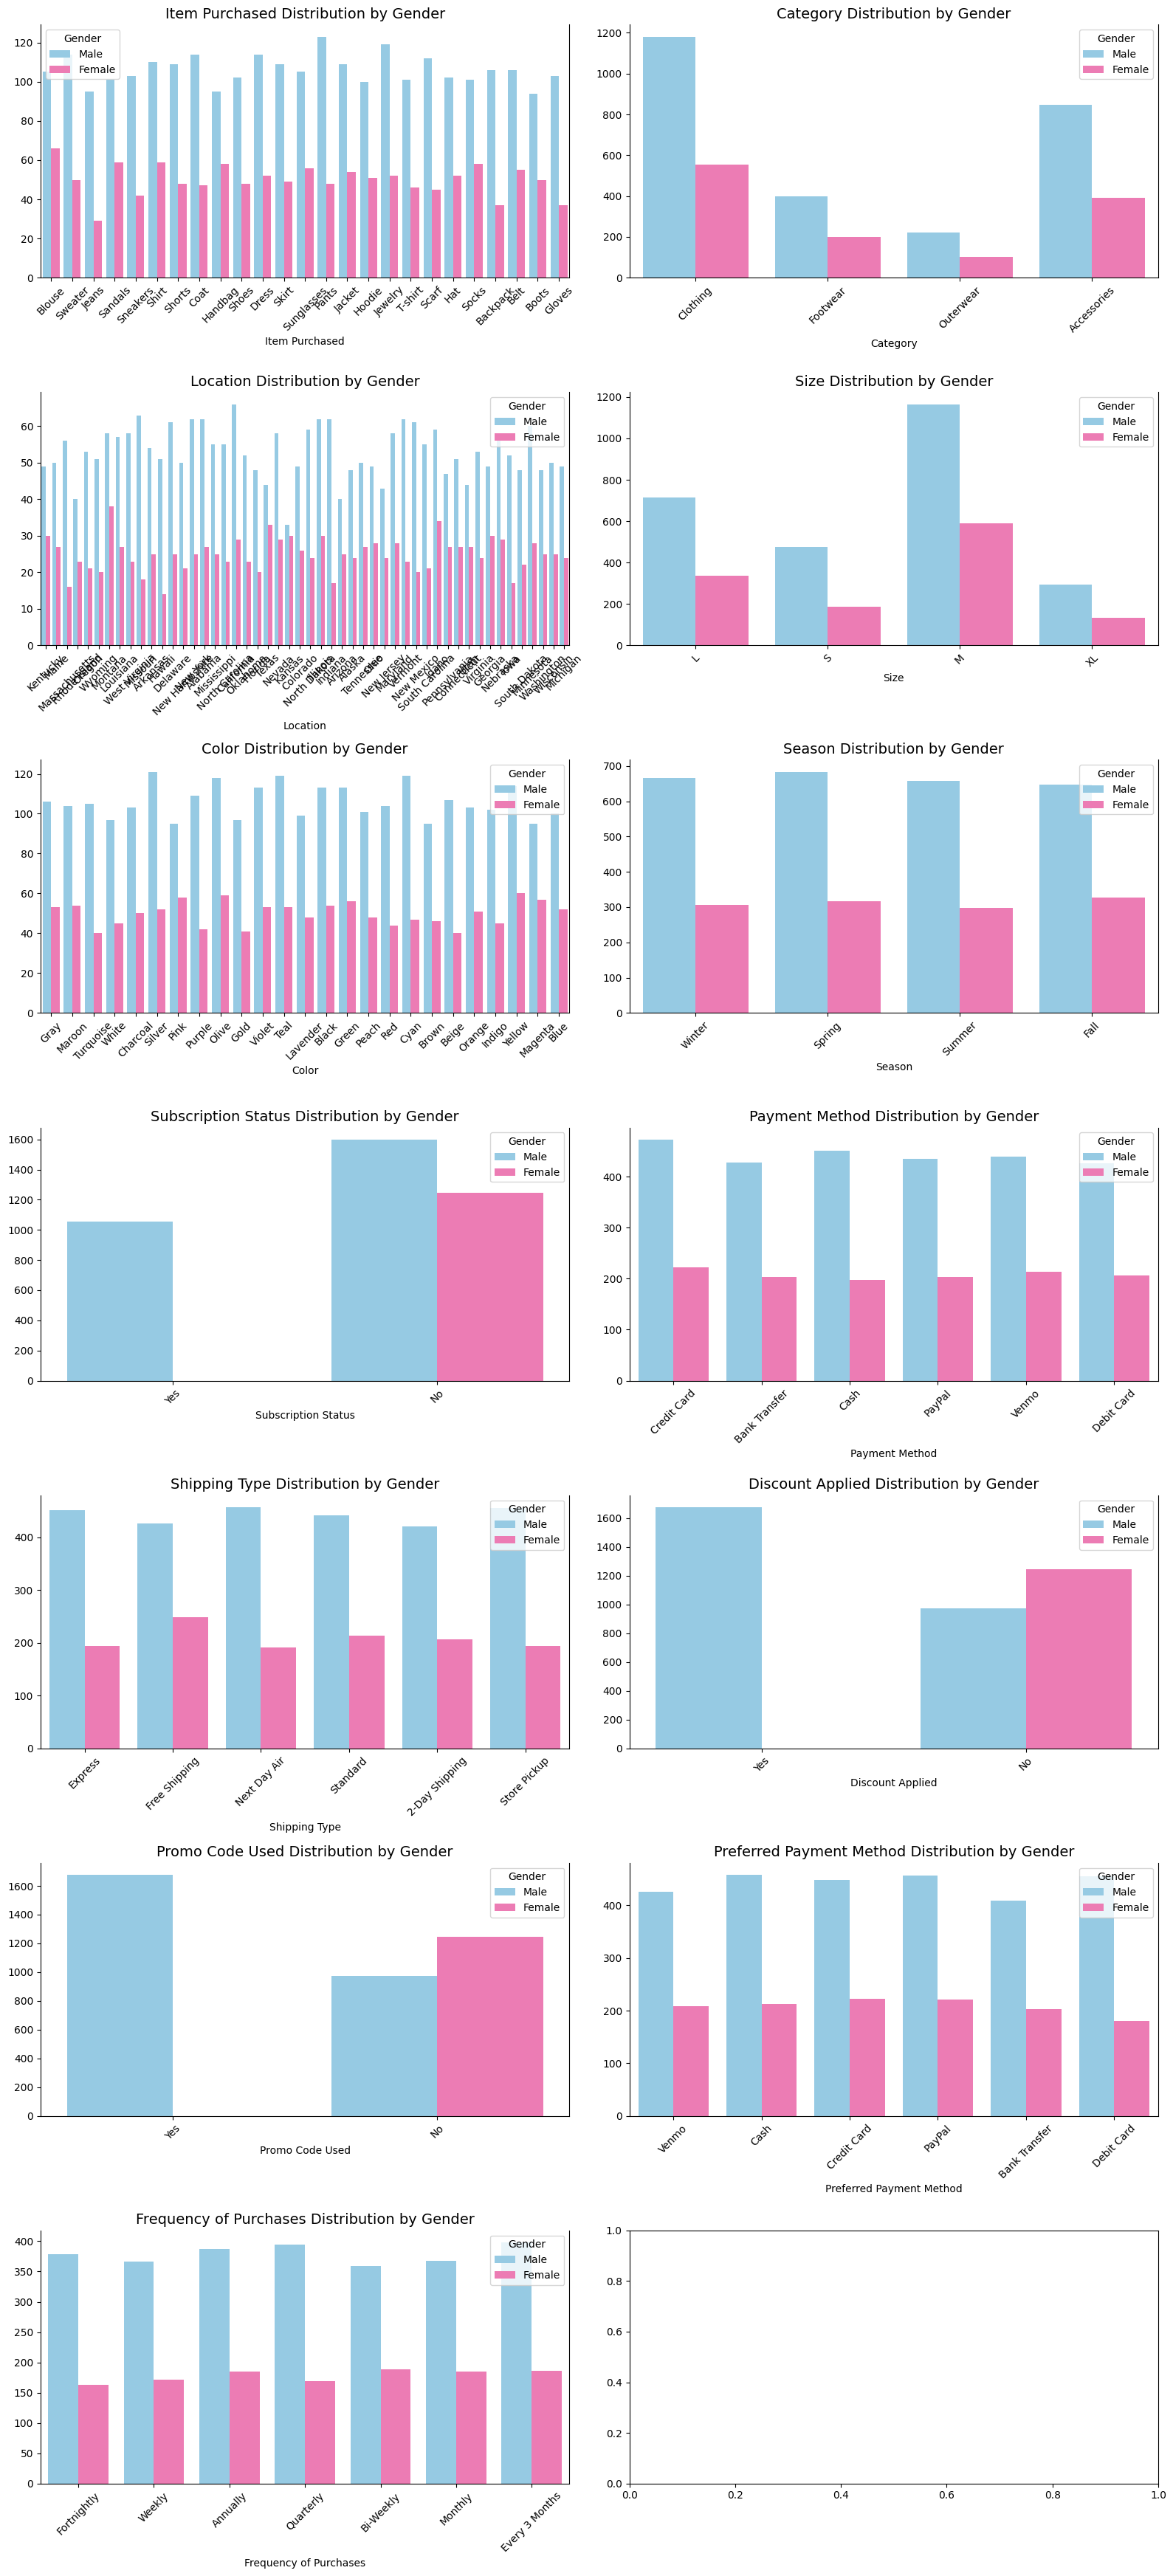

In [96]:
n_cols = 2
n_rows = (len(df.columns) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    sns.countplot(data=data, x=col, hue='Gender', palette=["#89CFF0", "#FF69B4"], ax=axes[idx])
    axes[idx].set_title(f"{col} Distribution by Gender", fontsize=14)
    axes[idx].set_ylabel('')
    axes[idx].spines['top'].set_visible(False)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [97]:
print(f"🔍 Insight: In {col}, Female customers tend to prefer ... while Male customers lean toward ...")


🔍 Insight: In Frequency of Purchases, Female customers tend to prefer ... while Male customers lean toward ...


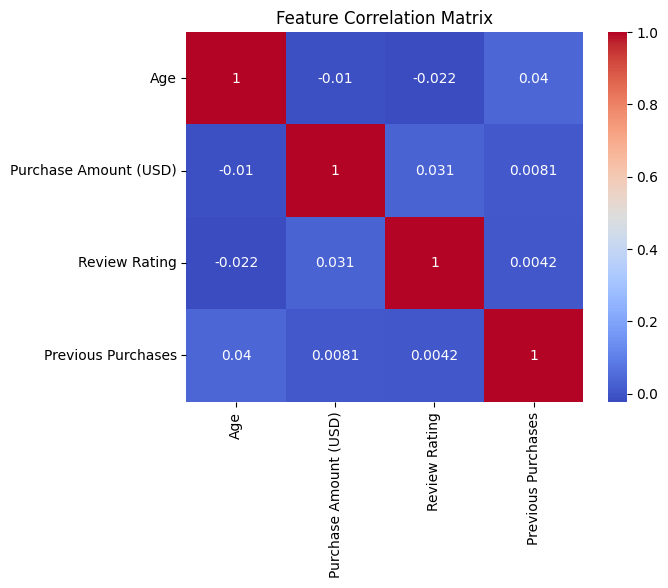

In [101]:
numeric_data = data.select_dtypes(include=np.number)
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Visualize All Categorical Features by Gender in a Grid